<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/Exercises_XP_StudentW6D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP — Large Language Models and GPT-2

Ce notebook présente les grands modèles linguistiques, la tokenisation, les identifiants de tokens, le pré-entraînement, le réglage fin et la génération de texte avec GPT-2.

## 🌟 Exercise 1 · What are Large Language Models?

Les **LLM**, ou grands modèles linguistiques, sont des modèles d’intelligence artificielle entraînés sur de très grandes quantités de textes.

Ils apprennent la structure de la langue, les relations entre les mots et la manière dont les phrases sont construites. Leur objectif principal est de prédire le prochain token à partir du contexte précédent.

Les LLM peuvent notamment :

- répondre à des questions ;
- générer du texte ;
- résumer ou traduire des documents ;
- analyser des sentiments ;
- produire du code.

GPT-2 est un modèle causal : il génère du texte en prédisant les tokens les uns après les autres.

In [1]:
%pip install --quiet transformers matplotlib --upgrade

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("Libraries installed and imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 24.2 MB/s eta 0:00:00
Libraries installed and imported successfully!


### 1.3 Load GPT for causal text generation

Le tokenizer transforme le texte en identifiants numériques. Le modèle GPT-2 utilise ensuite ces identifiants pour comprendre le contexte et prédire la suite du texte.

In [2]:
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# GPT-2 does not define a padding token by default.
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

if None in (model_name, tokenizer, model):
    raise ValueError(
        "Fill in model_name, tokenizer, and model before continuing."
    )

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next token in a sequence.
It can generate text by extending an initial prompt token by token.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next token in a sequence.
It can generate text by extending an initial prompt token by token.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization

La **tokenisation** consiste à découper une phrase en petites unités appelées **tokens**.

Un token peut être un mot complet, une partie d’un mot, un signe de ponctuation ou un espace associé à un mot. Chaque token reçoit ensuite un nombre appelé **Token ID**.

Le modèle ne travaille donc pas directement avec les mots : il utilise leurs identifiants numériques.

Original Text: Hello, how are you today?
Tokens: ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', 'Ġtoday', '?']
Token IDs: [15496, 11, 703, 389, 345, 1909, 30]


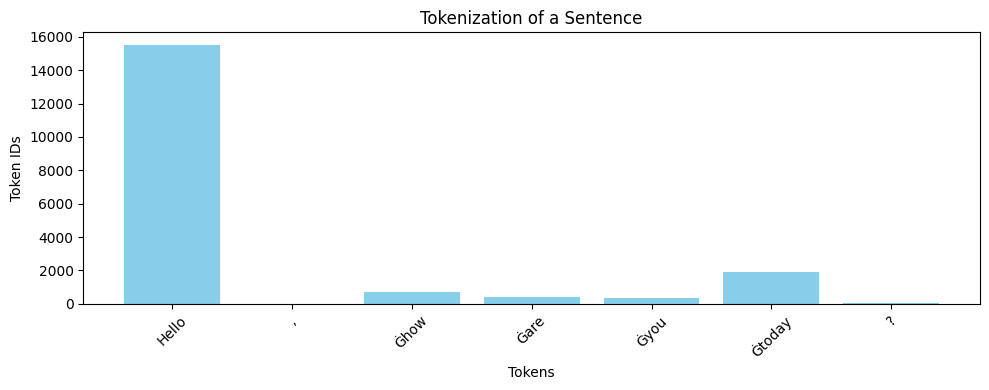

In [3]:
text = "Hello, how are you today?"

if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

# Tokenize the text and convert tokens to numerical IDs.
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

# Visualize the tokenization process.
x_label = "Tokens"
y_label = "Token IDs"
title = "Tokenization of a Sentence"

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🌟 Exercise 3 · Token IDs and Special Prefixes

Chaque token possède un identifiant unique dans le vocabulaire de GPT-2.

Le préfixe **`Ġ`** indique généralement qu’un espace était présent avant le token dans le texte original. Par exemple, `Ġhow` représente le mot `how` précédé d’un espace.

Ce symbole ne fait pas réellement partie du mot. Il permet au tokenizer de conserver l’information sur les espaces.

In [4]:
if "tokens" not in globals() or "token_ids" not in globals():
    raise ValueError(
        "Run Exercise 2 to define `tokens` and `token_ids` first."
    )

for token, token_id in zip(tokens, token_ids):
    space_info = (
        "preceded by a space"
        if token.startswith("Ġ")
        else "not marked as preceded by a space"
    )
    print(f"Token: '{token}' -> ID: {token_id} -> {space_info}")

Token: 'Hello' -> ID: 15496 -> not marked as preceded by a space
Token: ',' -> ID: 11 -> not marked as preceded by a space
Token: 'Ġhow' -> ID: 703 -> preceded by a space
Token: 'Ġare' -> ID: 389 -> preceded by a space
Token: 'Ġyou' -> ID: 345 -> preceded by a space
Token: 'Ġtoday' -> ID: 1909 -> preceded by a space
Token: '?' -> ID: 30 -> not marked as preceded by a space


## 🌟 Exercise 4 · Pre-training vs. Fine-tuning

### Pré-entraînement

Le **pré-entraînement** est la première phase d’apprentissage. Le modèle analyse une très grande quantité de textes et apprend à prédire le prochain token.

Cette phase lui permet d’apprendre le vocabulaire, la grammaire, la structure des phrases et certaines relations entre les concepts.

### Réglage fin

Le **réglage fin**, ou *fine-tuning*, consiste à poursuivre l’entraînement d’un modèle déjà pré-entraîné sur des données plus spécialisées.

Cette étape permet d’adapter le modèle à une tâche précise, par exemple l’analyse de sentiments, la classification de textes, la génération de descriptions ou les réponses dans un domaine particulier.

En résumé, le pré-entraînement donne au modèle des connaissances générales, tandis que le réglage fin le spécialise.

## 🌟 Exercise 5 · Generate Simple Text

Dans cet exercice, GPT-2 reçoit une phrase de départ appelée **prompt**. Il prédit ensuite le token suivant, l’ajoute au texte, puis répète ce processus jusqu’à atteindre la limite définie.

La phrase est écrite en anglais, car le modèle GPT-2 de base génère généralement de meilleurs résultats dans cette langue.

In [5]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "Artificial intelligence will change education by"

if input_text is None:
    raise ValueError("Set `input_text` before generating.")

# Set a seed to make the example easier to reproduce.
torch.manual_seed(42)

gen_kwargs = {
    "max_new_tokens": 60,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
}

generated_result = generator(input_text, **gen_kwargs)
output_text = generated_result[0]["generated_text"]

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'top_p', 'pad_token_id', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Input: Artificial intelligence will change education by
Generated Output: Artificial intelligence will change education by transforming our lives and create new opportunities for more people to achieve their goals and achieve their goals.

For more information on the research that we are doing and what you can do to improve your educational outcomes, visit this website or follow us on Twitter and Facebook.

About the Foundation:



### Explication des paramètres

- `max_new_tokens` fixe le nombre maximal de nouveaux tokens.
- `temperature` contrôle la créativité de la génération.
- `top_p` limite le choix aux tokens les plus probables.
- `do_sample=True` permet une génération probabiliste, donc le résultat peut varier.

Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)